# Lokal Processing: Scan, Clean, & Augmentation

Notebook ini menggabungkan semua tahapan pra-pemrosesan data yang dijalankan secara **lokal** (di komputer Anda):
1. **Data Scan**: Pemindaian dataset mentah buah dan sayur (fruits, vegetables, testings) untuk analisis jumlah dan contoh sebaran.
2. **Data Cleaning & Resize**: Menambahkan padding putih agar objek tetap proporsional (bujur sangkar) lalu di-resize ke 224x224 piksel.
3. **Data Augmentation**: Memperbanyak citra training asli menggunakan augmentasi OpenCV (custom pipeline).
4. **Testing Data Cleaning**: Membersihkan data testing tanpa augmentasi.
5. **Contoh Presentasi**: Pembuatan visualisasi augmentasi terpisah untuk naskah skripsi.

## 1. Import Library & Setup Environment

In [1]:
import os
import sys
import subprocess
import importlib
import shutil
import random
import math
import csv
from pathlib import Path
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_package(import_name, package_name=None, required=True):
    try:
        return importlib.import_module(import_name)
    except ModuleNotFoundError:
        package_name = package_name or import_name.split('.')[0]
        print(f'Installing missing package: {package_name}')
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package_name])
        except subprocess.CalledProcessError as exc:
            print(f'Warning: failed to install {package_name}: {exc}')
            if required:
                raise
            return None
        try:
            return importlib.import_module(import_name)
        except ModuleNotFoundError:
            if required:
                raise
            return None

Image = ensure_package('PIL.Image', 'pillow')
ImageDraw = ensure_package('PIL.ImageDraw', 'pillow').ImageDraw
ImageFont = ensure_package('PIL.ImageFont', 'pillow').ImageFont
cv2 = ensure_package('cv2', 'opencv-python')
tqdm = ensure_package('tqdm').tqdm

In [2]:
# Config shared paths
BASE_PATH = r'c:\Users\Muhamad Muslih\Desktop\modeling'
DATASET_ROOT = os.path.join(BASE_PATH, 'dataset')

TRAIN_ROOTS = [os.path.join(DATASET_ROOT, 'fruits'), os.path.join(DATASET_ROOT, 'vegetables')]
TEST_ROOT = os.path.join(DATASET_ROOT, 'testings')

OUTPUT_ROOT = os.path.join(BASE_PATH, 'outputs')
OUTPUT_SCAN_DIR = os.path.join(OUTPUT_ROOT, 'data_scan')
CLEANED_DATA_PATH = os.path.join(OUTPUT_ROOT, 'cleaned_data')
CLEANED_TESTING_ROOT = os.path.join(OUTPUT_ROOT, 'cleaned_testings')
CONTOH_AUG_ROOT = os.path.join(OUTPUT_ROOT, 'contoh_augmentasi')

os.makedirs(OUTPUT_SCAN_DIR, exist_ok=True)
os.makedirs(CLEANED_DATA_PATH, exist_ok=True)
os.makedirs(CLEANED_TESTING_ROOT, exist_ok=True)
os.makedirs(CONTOH_AUG_ROOT, exist_ok=True)

SAMPLE_PER_CLASS = 6
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}
IMAGE_EXT_TUPLE = ('.jpg', '.jpeg', '.png', '.webp')

TARGET_ORIGINAL_IMAGES = 100
TARGET_NON_ORIGINAL_IMAGES = 200
TARGET_IMAGES_PER_CLASS = 300

CATEGORIES = {
    "Fruits": [
        "fresh banana", "fresh mango", "fresh orange",
        "rotten banana", "rotten mango", "rotten orange"
    ],
    "Vegetables": [
        "fresh carrot", "fresh cucumber", "fresh tomato",
        "rotten carrot", "rotten cucumber", "rotten tomato"
    ]
}

## 2. Pemindaian Dataset Mentah (Data Scanning)

In [3]:
def collect_class_info(root_paths, source_label):
    rows = []
    for root in root_paths:
        if not os.path.exists(root): continue
        for class_name in sorted(os.listdir(root)):
            class_path = os.path.join(root, class_name)
            if not os.path.isdir(class_path): continue
            image_files = []
            for dirpath, _, filenames in os.walk(class_path):
                for fname in filenames:
                    if fname.lower().endswith(IMAGE_EXT_TUPLE):
                        image_files.append(os.path.join(dirpath, fname))
            image_files = sorted(image_files)
            sample_images = image_files[:SAMPLE_PER_CLASS] if image_files else []
            rows.append({
                'source': source_label,
                'root': root,
                'class_name': class_name,
                'num_images': len(image_files),
                'sample_images': sample_images
            })
    return pd.DataFrame(rows)

print("🔍 Scanning dataset mentah...")
train_df = collect_class_info(TRAIN_ROOTS, 'train')
test_df = collect_class_info([TEST_ROOT], 'test')
summary_df = pd.concat([train_df, test_df], ignore_index=True, sort=False).fillna({'num_images': 0})

summary_csv = os.path.join(OUTPUT_SCAN_DIR, 'data_scan_summary.csv')
summary_df.to_csv(summary_csv, index=False)
print('✅ Scan summary disimpan ke:', summary_csv)
summary_df.head(20)

🔍 Scanning dataset mentah...
✅ Scan summary disimpan ke: c:\Users\Muhamad Muslih\Desktop\modeling\outputs\data_scan\data_scan_summary.csv


,source,root,class_name,num_images,sample_images
0,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,fresh banana,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
1,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,fresh mango,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
2,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,fresh orange,244,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
3,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,rotten banana,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
4,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,rotten mango,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
5,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,rotten orange,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
6,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,fresh carrot,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
7,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,fresh cucumber,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
8,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,fresh tomato,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...
9,train,c:\Users\Muhamad Muslih\Desktop\modeling\datas...,rotten carrot,240,[c:\Users\Muhamad Muslih\Desktop\modeling\data...


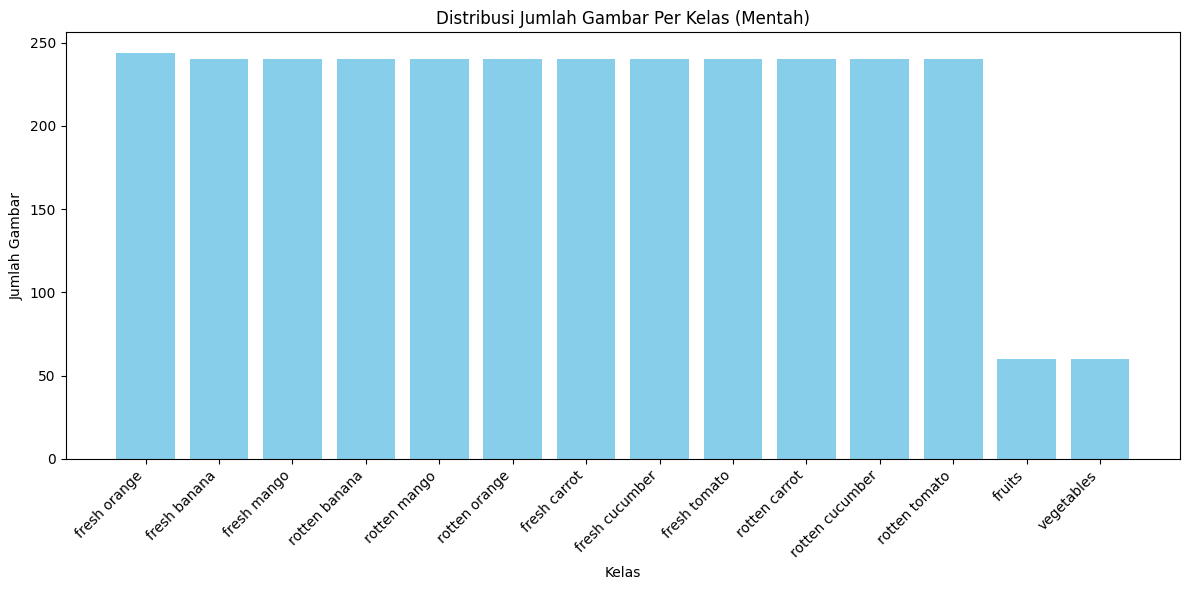

In [4]:
# Plot distribusi dataset mentah
dist = summary_df[['source','class_name','num_images']].sort_values(['num_images'], ascending=False)
dist_csv = os.path.join(OUTPUT_SCAN_DIR, 'class_distribution_raw.csv')
dist.to_csv(dist_csv, index=False)

plt.figure(figsize=(12, 6))
plt.bar(dist['class_name'], dist['num_images'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Distribusi Jumlah Gambar Per Kelas (Mentah)')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.tight_layout()
plot_path = os.path.join(OUTPUT_SCAN_DIR, 'class_distribution_raw.png')
plt.savefig(plot_path, dpi=200)
plt.show()

In [5]:
# Simpan contoh gambar mentah ke dalam grid visual
def save_sample_grid(image_paths, out_path, thumb_size=(224,224), cols=6):
    if not image_paths: return False
    images = []
    for p in image_paths[:cols]:
        try:
            img = Image.open(p).convert('RGB')
            img.thumbnail(thumb_size)
            images.append(img)
        except Exception as e:
            print('Failed to load', p, e)
    if not images: return False
    
    rows = math.ceil(len(images)/cols)
    canvas_w = thumb_size[0] * min(len(images), cols)
    canvas_h = thumb_size[1] * rows
    canvas = Image.new('RGB', (canvas_w, canvas_h), (255,255,255))
    
    for idx, img in enumerate(images):
        r, c = divmod(idx, cols)
        canvas.paste(img, (c * thumb_size[0], r * thumb_size[1]))
    
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    canvas.save(out_path)
    return True

samples_dir = os.path.join(OUTPUT_SCAN_DIR, 'samples')
for idx, row in summary_df.iterrows():
    if row['num_images'] > 0:
        out_name = f"{row['source']}_{row['class_name'].replace(' ', '_')}_samples.jpg"
        save_sample_grid(row['sample_images'], os.path.join(samples_dir, out_name))

## 3. Preprocessing: Cleaning & Augmentation

In [6]:
def collect_all_image_files(root_folder, exclude_path=None):
    image_files = []
    root_folder = os.path.abspath(root_folder)
    exclude_path = os.path.abspath(exclude_path) if exclude_path else None
    for current_root, _, files in os.walk(root_folder):
        current_root_abs = os.path.abspath(current_root)
        if exclude_path and (current_root_abs == exclude_path or current_root_abs.startswith(exclude_path + os.sep)):
            continue
        for file_name in files:
            if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                image_files.append(os.path.join(current_root, file_name))
    return image_files

# Set Up Pipeline Augmentasi
class CV2AugmentationPipeline:
    def __call__(self, image):
        augmented = image.copy()
        height, width = augmented.shape[:2]
        if random.random() < 0.5: augmented = cv2.flip(augmented, 1)
        if random.random() < 0.35:
            alpha = random.uniform(0.8, 1.25)
            beta = random.randint(-20, 20)
            augmented = cv2.convertScaleAbs(augmented, alpha=alpha, beta=beta)
        if random.random() < 0.3:
            angle = random.uniform(-20, 20)
            matrix = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
            augmented = cv2.warpAffine(augmented, matrix, (width, height), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
        if random.random() < 0.2:
            kernel = random.choice([3, 5])
            augmented = cv2.GaussianBlur(augmented, (kernel, kernel), 0)
        if random.random() < 0.2:
            noise = np.random.normal(0, 10, augmented.shape).astype(np.int16)
            augmented = np.clip(augmented.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        if random.random() < 0.15:
            src = np.float32([[0, 0], [width - 1, 0], [0, height - 1], [width - 1, height - 1]])
            shift = max(1, int(min(height, width) * 0.05))
            dst = np.float32([
                [random.randint(0, shift), random.randint(0, shift)],
                [width - 1 - random.randint(0, shift), random.randint(0, shift)],
                [random.randint(0, shift), height - 1 - random.randint(0, shift)],
                [width - 1 - random.randint(0, shift), height - 1 - random.randint(0, shift)],
            ])
            transform = cv2.getPerspectiveTransform(src, dst)
            augmented = cv2.warpPerspective(augmented, transform, (width, height), borderMode=cv2.BORDER_REFLECT_101)
        return {'image': augmented}

print('✅ Memakai OpenCV augmentation pipeline')
augmentation = CV2AugmentationPipeline()

def convert_webp_to_jpg(image_path):
    try:
        if image_path.lower().endswith('.webp'):
            img = Image.open(image_path)
            jpg_path = os.path.splitext(image_path)[0] + '.jpg'
            if img.mode == 'RGBA':
                rgb_img = Image.new('RGB', img.size, (255, 255, 255))
                rgb_img.paste(img, mask=img.split()[3])
                rgb_img.save(jpg_path, quality=95)
            else:
                img.convert('RGB').save(jpg_path, quality=95)
            os.remove(image_path)
            return jpg_path
    except Exception as e:
        print(f"❌ Error convert webp: {e}")
    return image_path

def resize_with_padding(image_path, output_path, target_size=224):
    try:
        img = Image.open(image_path)
        img = img.convert('RGBA') if img.mode in {'RGBA', 'LA', 'P'} else img.convert('RGB')
        if img.mode == 'RGBA':
            bg = Image.new('RGB', img.size, (255, 255, 255))
            bg.paste(img, mask=img.getchannel('A'))
            img = bg
        w, h = img.size
        max_side = max(w, h)
        canvas = Image.new('RGB', (max_side, max_side), (255, 255, 255))
        canvas.paste(img, ((max_side - w) // 2, (max_side - h) // 2))
        resized = canvas.resize((target_size, target_size), Image.Resampling.LANCZOS)
        resized.save(output_path, quality=95)
        return True
    except Exception as e:
        print(f"❌ Error resizing {image_path}: {e}")
        return False

def augment_image(image_path, output_folder, start_index, num_augmentations=1):
    try:
        image = cv2.imread(image_path)
        if image is None: return 0
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        written = 0
        for i in range(num_augmentations):
            augmented = augmentation(image=image)
            aug_image = augmented['image']
            out_name = f"aug_{start_index + i:05d}.jpg"
            out_path = os.path.join(output_folder, out_name)
            if cv2.imwrite(out_path, cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR)):
                written += 1
        return written
    except Exception as e:
        print(f"❌ Error augment: {e}")
        return 0

def clean_folder_images(source_images, output_folder, prefix, target_count=None):
    cleaned_paths = []
    if target_count is not None and len(source_images) > target_count:
        source_images = random.sample(source_images, target_count)

    pbar = tqdm(source_images, desc=f"Clean {prefix}", unit="img", ncols=80)
    for idx, img_path in enumerate(pbar):
        try:
            pbar.set_description(f"Clean: {Path(img_path).name[:28]}")
            working_path = img_path
            if img_path.lower().endswith('.webp'):
                working_path = convert_webp_to_jpg(img_path)
            out_name = f"{prefix}_{idx:05d}.jpg"
            out_path = os.path.join(output_folder, out_name)
            if resize_with_padding(working_path, out_path, target_size=224):
                cleaned_paths.append(out_path)
        except Exception as e:
            print(f"❌ Error: {e}")
    pbar.close()
    return cleaned_paths

✅ Memakai OpenCV augmentation pipeline


In [7]:
# Proses data training (Clean + Augmentasi)
def process_category(category_path, category_name, type_name):
    if not os.path.exists(category_path): return 0
    print(f"\n📁 Processing Training: {type_name} > {category_name}")
    data_asli_path = os.path.join(category_path, 'data asli')
    data_asli_images = collect_all_image_files(data_asli_path) if os.path.exists(data_asli_path) else []
    other_images = collect_all_image_files(category_path, exclude_path=data_asli_path)

    output_category_folder = os.path.join(CLEANED_DATA_PATH, type_name.capitalize(), category_name)
    if os.path.exists(output_category_folder): shutil.rmtree(output_category_folder)
    os.makedirs(output_category_folder, exist_ok=True)

    # Maksimal 40 data asli jepretan sendiri
    selected_original = data_asli_images
    if len(selected_original) > 40:
        selected_original = random.sample(data_asli_images, 40)

    original_clean_paths = clean_folder_images(selected_original, output_category_folder, "origclean")
    cleaned_other_paths = clean_folder_images(other_images, output_category_folder, "clean", target_count=TARGET_NON_ORIGINAL_IMAGES)

    # Augmentasi
    remaining = TARGET_ORIGINAL_IMAGES - len(original_clean_paths)
    aug_index = 0
    if remaining > 0 and len(original_clean_paths) > 0:
        aug_per_image = remaining // len(original_clean_paths)
        extra = remaining % len(original_clean_paths)
        
        pbar = tqdm(original_clean_paths, desc=f"Augment {category_name}", unit="img", ncols=80)
        for idx, img_path in enumerate(pbar):
            pbar.set_description(f"Augment: {Path(img_path).stem[:28]}")
            num_aug = aug_per_image + (1 if idx < extra else 0)
            if num_aug > 0:
                written = augment_image(img_path, output_category_folder, aug_index, num_augmentations=num_aug)
                aug_index += written
        pbar.close()
        
        # Guard loop
        current_total = len([p for p in glob.glob(os.path.join(output_category_folder, '*.jpg')) if os.path.basename(p).startswith(('origclean_', 'aug_'))])
        guard = 0
        while current_total < TARGET_ORIGINAL_IMAGES and guard < TARGET_ORIGINAL_IMAGES * 3:
            source = random.choice(original_clean_paths)
            written = augment_image(source, output_category_folder, aug_index, num_augmentations=1)
            aug_index += written
            current_total = len([p for p in glob.glob(os.path.join(output_category_folder, '*.jpg')) if os.path.basename(p).startswith(('origclean_', 'aug_'))])
            guard += 1

    # Trimming / Balancing
    final_images = sorted(glob.glob(os.path.join(output_category_folder, '*.jpg')))
    original_files = [p for p in final_images if os.path.basename(p).startswith(('origclean_', 'aug_'))]
    other_files = [p for p in final_images if os.path.basename(p).startswith('clean_')]

    if len(original_files) > TARGET_ORIGINAL_IMAGES:
        keep = set(random.sample(original_files, TARGET_ORIGINAL_IMAGES))
        for p in original_files:
            if p not in keep: os.remove(p)
        original_files = [p for p in glob.glob(os.path.join(output_category_folder, '*.jpg')) if os.path.basename(p).startswith(('origclean_', 'aug_'))]

    if len(other_files) > TARGET_NON_ORIGINAL_IMAGES:
        keep = set(random.sample(other_files, TARGET_NON_ORIGINAL_IMAGES))
        for p in other_files:
            if p not in keep: os.remove(p)
        other_files = [p for p in glob.glob(os.path.join(output_category_folder, '*.jpg')) if os.path.basename(p).startswith('clean_')]

    final_total = len(original_files) + len(other_files)
    print(f"✅ Kategori {category_name} selesai. Total: {final_total} file.")
    return final_total

print("🚀 Memulai cleaning & augmentasi data training...")
if os.path.exists(CLEANED_DATA_PATH): shutil.rmtree(CLEANED_DATA_PATH)
os.makedirs(CLEANED_DATA_PATH, exist_ok=True)

total_train_images = 0
for type_name, categories_list in CATEGORIES.items():
    type_path = os.path.join(DATASET_ROOT, type_name.lower())
    for category in categories_list:
        category_path = os.path.join(type_path, category)
        count = process_category(category_path, category, type_name)
        total_train_images += count
print(f"\n✅ Selesai. Total gambar training bersih: {total_train_images}")

🚀 Memulai cleaning & augmentasi data training...

📁 Processing Training: Fruits > fresh banana


Augment: origclean_00039: 100%|████████████████| 40/40 [00:01<00:00, 33.26img/s]


✅ Kategori fresh banana selesai. Total: 300 file.

📁 Processing Training: Fruits > fresh mango


Augment: origclean_00039: 100%|████████████████| 40/40 [00:00<00:00, 59.62img/s]


✅ Kategori fresh mango selesai. Total: 300 file.

📁 Processing Training: Fruits > fresh orange


...

✅ Kategori rotten carrot selesai. Total: 300 file.

📁 Processing Training: Vegetables > rotten cucumber


Augment: origclean_00039: 100%|████████████████| 40/40 [00:02<00:00, 17.72img/s]


✅ Kategori rotten cucumber selesai. Total: 300 file.

📁 Processing Training: Vegetables > rotten tomato


Augment: origclean_00039: 100%|████████████████| 40/40 [00:03<00:00, 10.59img/s]

✅ Kategori rotten tomato selesai. Total: 300 file.

✅ Selesai. Total gambar training bersih: 3600


In [8]:
# Proses data testing (Clean saja)
def clean_testing_dataset(source_root, output_root):
    if not os.path.exists(source_root): return 0
    total_saved = 0
    type_folders = [d for d in sorted(os.listdir(source_root)) if os.path.isdir(os.path.join(source_root, d))]
    for type_folder in type_folders:
        type_path = os.path.join(source_root, type_folder)
        output_type_folder = os.path.join(output_root, type_folder.capitalize())
        os.makedirs(output_type_folder, exist_ok=True)
        
        category_folders = [d for d in sorted(os.listdir(type_path)) if os.path.isdir(os.path.join(type_path, d))]
        for category_folder in category_folders:
            category_path = os.path.join(type_path, category_folder)
            image_files = collect_all_image_files(category_path)
            output_category_folder = os.path.join(output_type_folder, category_folder)
            os.makedirs(output_category_folder, exist_ok=True)
            
            print(f"Cleaning testing: {type_folder}/{category_folder} ({len(image_files)} gambar)")
            cleaned_paths = clean_folder_images(image_files, output_category_folder, "test")
            total_saved += len(cleaned_paths)
    return total_saved

print("🚀 Memulai cleaning data testing...")
if os.path.exists(CLEANED_TESTING_ROOT): shutil.rmtree(CLEANED_TESTING_ROOT)
os.makedirs(CLEANED_TESTING_ROOT, exist_ok=True)

total_test_images = clean_testing_dataset(TEST_ROOT, CLEANED_TESTING_ROOT)
print(f"\n✅ Selesai. Total gambar testing bersih: {total_test_images}")

🚀 Memulai cleaning data testing...
Cleaning testing: fruits/fresh banana (10 gambar)


Clean: test_fresh_banana_010.jpg: 100%|████████| 10/10 [00:08<00:00,  1.22img/s]


Cleaning testing: fruits/fresh mango (10 gambar)


Clean: test_fresh_mango_010.jpg: 100%|█████████| 10/10 [00:10<00:00,  1.06s/img]


Cleaning testing: fruits/fresh orange (10 gambar)


...

Cleaning testing: vegetables/rotten cucumber (10 gambar)


Clean: test_rotten_cucumber_010.jpg: 100%|█████| 10/10 [00:01<00:00,  5.56img/s]


Cleaning testing: vegetables/rotten tomato (10 gambar)


Clean: test_rotten_tomato_010.jpg: 100%|███████| 10/10 [00:02<00:00,  3.53img/s]


✅ Selesai. Total gambar testing bersih: 120


## 4. Analisis & Verifikasi Output

In [9]:
# Verifikasi keberadaan dan jumlah file hasil cleaned_data
statistics = []
total_files = 0

if os.path.exists(CLEANED_DATA_PATH):
    for type_folder in sorted(os.listdir(CLEANED_DATA_PATH)):
        type_path = os.path.join(CLEANED_DATA_PATH, type_folder)
        if os.path.isdir(type_path):
            for category_folder in sorted(os.listdir(type_path)):
                category_path = os.path.join(type_path, category_folder)
                if os.path.isdir(category_path):
                    images = [f for f in os.listdir(category_path) if f.lower().endswith(('.jpg', '.png'))]
                    num_images = len(images)
                    total_files += num_images
                    statistics.append({
                        'Tipe': type_folder,
                        'Kategori': category_folder,
                        'Total Gambar': num_images
                    })

df_stats = pd.DataFrame(statistics)
print("\n📈 STATISTIK DATASET TRAINING BERSIH")
print("="*50)
if not df_stats.empty:
    print(df_stats.to_string(index=False))
    print(f"\n✅ TOTAL: {total_files} file")
else:
    print("❌ Tidak ada data training hasil cleaning.")


📈 STATISTIK DATASET TRAINING BERSIH
      Tipe        Kategori  Total Gambar
    Fruits    fresh banana           300
    Fruits     fresh mango           300
    Fruits    fresh orange           300
    Fruits   rotten banana           300
    Fruits    rotten mango           300
    Fruits   rotten orange           300
Vegetables    fresh carrot           300
Vegetables  fresh cucumber           300
Vegetables    fresh tomato           300
Vegetables   rotten carrot           300
Vegetables rotten cucumber           300
Vegetables   rotten tomato           300

✅ TOTAL: 3600 file


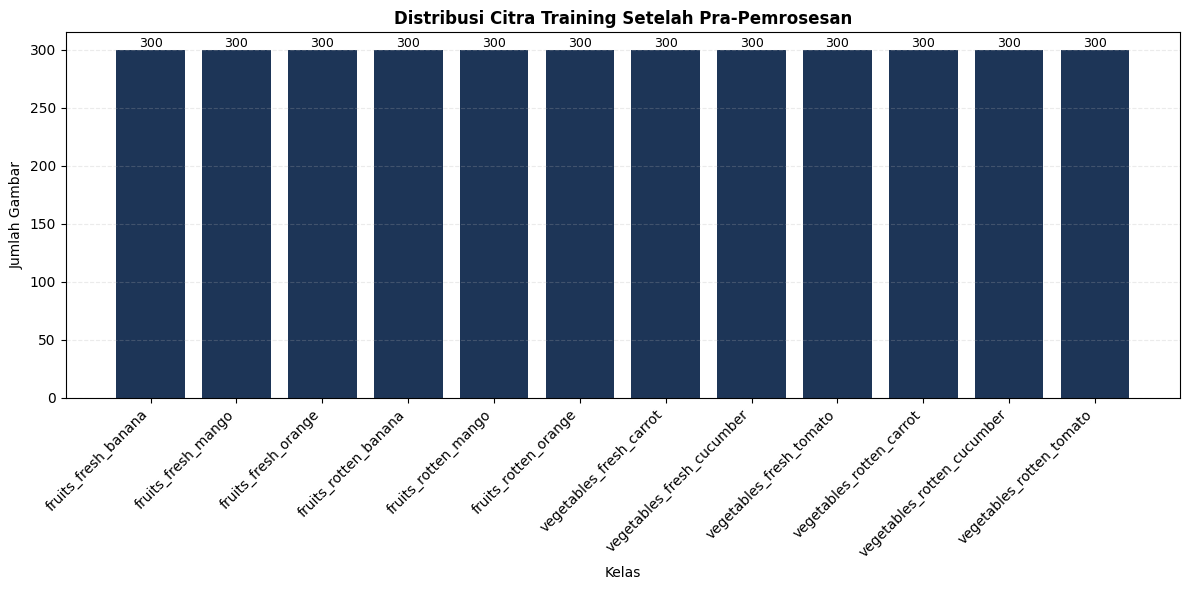

In [10]:
# Plot diagram batang untuk distribusi data bersih
if not df_stats.empty:
    df_stats['Class'] = df_stats['Tipe'] + '_' + df_stats['Kategori']
    df_stats['Class'] = df_stats['Class'].str.lower().str.replace(' ', '_')
    
    plt.figure(figsize=(12, 6))
    bars = plt.bar(df_stats['Class'], df_stats['Total Gambar'], color='#1d3557')
    plt.title("Distribusi Citra Training Setelah Pra-Pemrosesan", fontweight="bold")
    plt.xlabel("Kelas")
    plt.ylabel("Jumlah Gambar")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.25)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height())}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_SCAN_DIR, 'class_distribution_cleaned.png'), dpi=200)
    plt.show()

## 5. Eksperimen Contoh Augmentasi untuk Lampiran Skripsi

In [11]:
# Generate contoh augmentasi deterministik untuk dimasukkan ke Bab 3/4 naskah skripsi
print("🚀 Membuat berkas contoh augmentasi untuk presentasi/naskah...")

AUGMENTATIONS = [
    ("01_flip_plus_clean", "flip", "Horizontal flip"),
    ("02_brightness_contrast_plus_clean", "brightness_contrast", "Brightness and contrast"),
    ("03_rotation_plus_clean", "rotation", "Rotation"),
    ("04_gaussian_noise_plus_clean", "gaussian_noise", "Gaussian noise"),
    ("05_gaussian_blur_plus_clean", "gaussian_blur", "Gaussian blur"),
    ("06_perspective_plus_clean", "perspective", "Perspective"),
]

def slugify(value: str) -> str:
    return value.strip().lower().replace("&", "and").replace("/", "_").replace("\\", "_").replace(" ", "_")

def collect_data_asli_samples() -> list[dict]:
    samples = []
    for type_name, category_names in CATEGORIES.items():
        source_type_dir = os.path.join(DATASET_ROOT, type_name.lower())
        for category_name in category_names:
            data_asli_dir = os.path.join(source_type_dir, category_name, 'data asli')
            if not os.path.exists(data_asli_dir): 
                data_asli_dir = os.path.join(source_type_dir, category_name)
                if not os.path.exists(data_asli_dir): continue
            image_paths = sorted([
                os.path.join(data_asli_dir, f)
                for f in os.listdir(data_asli_dir)
                if os.path.isfile(os.path.join(data_asli_dir, f)) and os.path.splitext(f)[1].lower() in IMAGE_EXTENSIONS
            ])
            if not image_paths: continue
            selected_path = image_paths[len(image_paths) // 2]
            slug = slugify(f"{type_name}_{category_name}")
            samples.append({
                "type": type_name,
                "category": category_name,
                "slug": slug,
                "source": selected_path
            })
    return samples

def apply_deterministic_augmentation(img_array, aug_name):
    if aug_name == "flip":
        augmented = cv2.flip(img_array, 1)
    elif aug_name == "brightness_contrast":
        augmented = cv2.convertScaleAbs(img_array, alpha=1.2, beta=15)
    elif aug_name == "rotation":
        height, width = img_array.shape[:2]
        matrix = cv2.getRotationMatrix2D((width / 2, height / 2), 15, 1.0)
        augmented = cv2.warpAffine(img_array, matrix, (width, height), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT_101)
    elif aug_name == "gaussian_noise":
        rng = np.random.default_rng(42)
        noise = rng.normal(0, 15, img_array.shape).astype(np.int16)
        augmented = np.clip(img_array.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    elif aug_name == "gaussian_blur":
        augmented = cv2.GaussianBlur(img_array, (5, 5), 0)
    elif aug_name == "perspective":
        height, width = img_array.shape[:2]
        shift = max(1, int(min(height, width) * 0.08))
        src = np.float32([[0, 0], [width - 1, 0], [0, height - 1], [width - 1, height - 1]])
        dst = np.float32([[shift, shift], [width - 1 - shift, shift], [shift, height - 1 - shift], [width - 1 - shift, height - 1 - shift]])
        transform = cv2.getPerspectiveTransform(src, dst)
        augmented = cv2.warpPerspective(img_array, transform, (width, height), borderMode=cv2.BORDER_REFLECT_101)
    else:
        augmented = img_array.copy()
    return Image.fromarray(augmented)

def label_image(image, label) -> Image.Image:
    label_height = 46
    card = Image.new("RGB", (224, 224 + label_height), (248, 248, 248))
    card.paste(image, (0, label_height))
    draw = ImageDraw(card)
    try: font = ImageFont.load_default()
    except: font = None
    draw.rectangle((0, 0, 224, label_height), fill=(34, 40, 49))
    draw.multiline_text((8, 8), label[:60], fill=(255, 255, 255), font=font, spacing=2)
    return card

def make_contact_sheet(items, output_path, cols=4):
    if not items: return
    labelled = [label_image(image, label) for image, label in items]
    tile_w, tile_h = labelled[0].size
    rows = int(np.ceil(len(labelled) / cols))
    gap, margin = 16, 18
    sheet = Image.new("RGB", (cols * tile_w + (cols - 1) * gap + margin * 2, rows * tile_h + (rows - 1) * gap + margin * 2), (255, 255, 255))
    for index, tile in enumerate(labelled):
        row, col = divmod(index, cols)
        sheet.paste(tile, (margin + col * (tile_w + gap), margin + row * (tile_h + gap)))
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    sheet.save(output_path, quality=95)

if os.path.exists(CONTOH_AUG_ROOT): shutil.rmtree(CONTOH_AUG_ROOT)
os.makedirs(CONTOH_AUG_ROOT, exist_ok=True)
raw_clean_dir = os.path.join(CONTOH_AUG_ROOT, "00_data_asli_dan_clean")
clean_only_dir = os.path.join(CONTOH_AUG_ROOT, "00_clean_saja")
visual_dir = os.path.join(CONTOH_AUG_ROOT, "ringkasan_visual")
os.makedirs(raw_clean_dir, exist_ok=True)
os.makedirs(clean_only_dir, exist_ok=True)
os.makedirs(visual_dir, exist_ok=True)

samples = collect_data_asli_samples()
manifest_rows, clean_images = [], []
for s in samples:
    source = s["source"]
    slug = s["slug"]
    class_label = f"{s['type']} / {s['category']}"
    ext = os.path.splitext(source)[1].lower()
    shutil.copy2(source, os.path.join(raw_clean_dir, f"{slug}_data_asli{ext}"))
    
    clean_path = os.path.join(clean_only_dir, f"{slug}_clean.jpg")
    resize_with_padding(source, clean_path, target_size=224)
    shutil.copy2(clean_path, os.path.join(raw_clean_dir, f"{slug}_clean.jpg"))
    
    cleaned_img = Image.open(clean_path)
    clean_images.append((cleaned_img, slug, class_label))
    manifest_rows.append({
        "folder": "00_clean_saja",
        "type": s["type"],
        "category": s["category"],
        "augmentation": "clean_only",
        "source_path": source,
        "clean_path": clean_path,
        "augmented_path": ""
    })

raw_clean_items = [(img, f"clean\n{lbl}") for img, _, lbl in clean_images]
make_contact_sheet(raw_clean_items, os.path.join(visual_dir, "00_clean_saja_contact_sheet.jpg"), cols=4)

first_sample_transforms = []
first_clean, first_slug, first_label = clean_images[0]
first_sample_transforms.append((first_clean, f"clean\n{first_label}"))

for folder_name, aug_name, aug_label in AUGMENTATIONS:
    aug_dir = os.path.join(CONTOH_AUG_ROOT, folder_name)
    os.makedirs(aug_dir, exist_ok=True)
    sheet_items = []
    for img, slug, class_label in clean_images:
        clean_p = os.path.join(aug_dir, f"{slug}_clean.jpg")
        aug_p = os.path.join(aug_dir, f"{slug}_{aug_name}_clean.jpg")
        img.save(clean_p, quality=95)
        
        img_arr = np.array(img)
        augmented_img = apply_deterministic_augmentation(img_arr, aug_name)
        augmented_img.save(aug_p, quality=95)
        sheet_items.append((img, f"clean\n{class_label}"))
        sheet_items.append((augmented_img, f"{aug_label}\n{class_label}"))
        
        manifest_rows.append({
            "folder": folder_name,
            "type": class_label.split(" / ")[0],
            "category": class_label.split(" / ")[1],
            "augmentation": aug_name,
            "source_path": "",
            "clean_path": clean_p,
            "augmented_path": aug_p
        })
        if slug == first_slug: first_sample_transforms.append((augmented_img, f"{aug_label}\n{first_label}"))
    make_contact_sheet(sheet_items, os.path.join(visual_dir, f"{folder_name}_contact_sheet.jpg"), cols=4)

make_contact_sheet(first_sample_transforms, os.path.join(visual_dir, "semua_transform_satu_contoh.jpg"), cols=4)

manifest_path = os.path.join(CONTOH_AUG_ROOT, "manifest.csv")
with open(manifest_path, "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=["folder", "type", "category", "augmentation", "source_path", "clean_path", "augmented_path"])
    writer.writeheader()
    writer.writerows(manifest_rows)
print("✅ Visualisasi contoh augmentasi berhasil dibuat di:", CONTOH_AUG_ROOT)

🚀 Membuat berkas contoh augmentasi untuk presentasi/naskah...
✅ Visualisasi contoh augmentasi berhasil dibuat di: c:\Users\Muhamad Muslih\Desktop\modeling\outputs\contoh_augmentasi
